In [43]:
library(tidyverse)

plot_cv_mean_scatter <- function(file_path) {
    # Read data from the CSV file with multiple spaces as delimiter
    df <- read.table(file_path, header = TRUE, sep = "\t", encoding = "UTF-16LE")

  # Calculate coefficient of variation and mean for each gene
  cv_mean_data <- df %>%
    group_by(Gene_Name) %>%
    summarise(CV = sd(Norm_Count) / mean(Norm_Count), Mean = mean(Norm_Count))

  # Plot the scatter plot with 95% confidence interval
  df %>%
    ggplot(aes(x = Mean, y = CV, color = factor(Strains), shape = factor(Strains))) +
    geom_point(size = 3) +
    stat_summary(aes(x = Mean, y = CV), fun = mean, geom = "bar", fill = "red", alpha = 0.5, position = position_dodge(width = 0.75),
                 width = 0.7, show.legend = FALSE) +
    stat_summary(aes(x = Mean, y = CV), fun.data = mean_cl_normal, geom = "errorbar", color = "red",
                 position = position_dodge(width = 0.75), width = 0.2) +
    labs(title = "Scatter Plot with Coefficient of Variation and 95% Confidence Interval",
         x = "Mean",
         y = "Coefficient of Variation") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}


In [44]:
# Example usage with a file path
file_path <- "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/CV_analysis/CV_varaintions_input.csv"
plot_cv_mean_scatter(file_path)


ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! object 'Mean' not found

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)


In [45]:
library(tidyverse)
library(broom)

In [48]:
  file_path <- "/mnt/home3/miska/nm667/scratch/inProgress/mice_PiRNA/analysis/CV_analysis/CV_varaintions_input.csv"
  df <- read.table(file_path, header = TRUE, sep = "\t", encoding = "UTF-16LE")

In [49]:
# Calculate mean, CV, and CI for each group
summary_stats <- df %>%
  group_by(Timepoint, Strains, Gene_Name) %>%
  summarize(
    Mean = mean(Norm_Count),
    CV = sd(Norm_Count) / Mean * 100,
    Lower_CI = Mean - qt(0.975, df = n() - 1) * (sd(Norm_Count) / sqrt(n())),
    Upper_CI = Mean + qt(0.975, df = n() - 1) * (sd(Norm_Count) / sqrt(n()))
  )

`summarise()` has grouped output by 'Timepoint', 'Strains'. You can override
using the `.groups` argument.


Warning message:
“`position_dodge()` requires non-overlapping x intervals”
Warning message:
“`position_dodge()` requires non-overlapping x intervals”
Warning message:
“Removed 28033 rows containing missing values (`geom_point()`).”


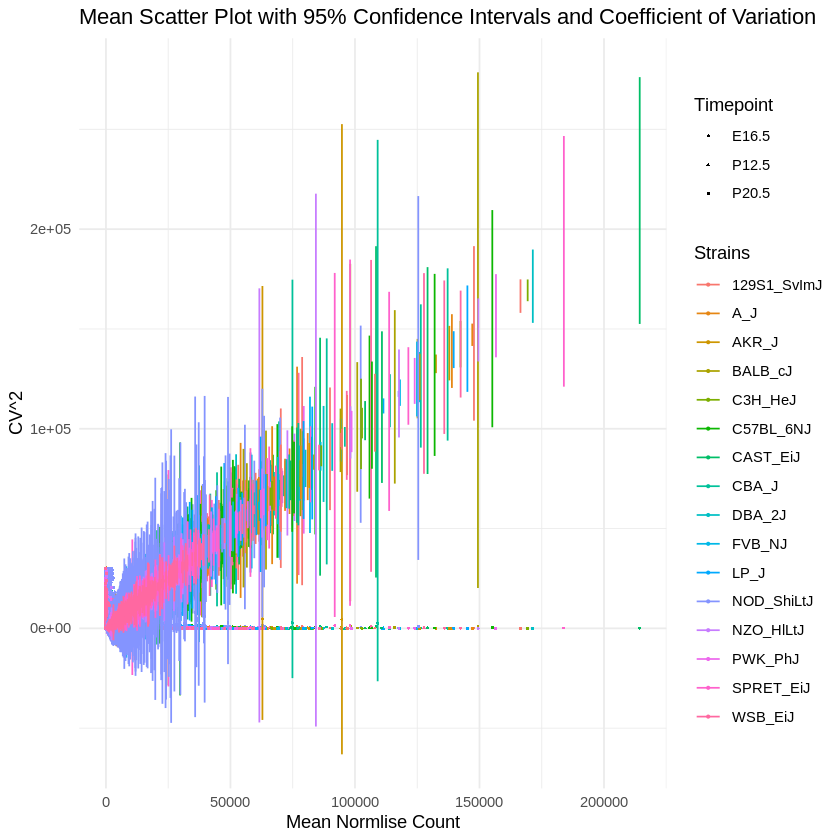

In [54]:
# Plotting
ggplot(summary_stats, aes(x = Mean, y = CV*CV, color = Strains, shape = Timepoint)) +
  geom_point(position = position_dodge(width = 0.2), size = 0.5) +
  geom_errorbar(
    aes(ymin = Lower_CI, ymax = Upper_CI),
    position = position_dodge(width = 0.2),
    width = 0.2
  ) +
  labs(title = "Mean Scatter Plot with 95% Confidence Intervals and Coefficient of Variation",
       x = "Mean Normlise Count", y = "CV^2") +
  theme_minimal()